

# **EDA - Exploratory Data Analysis**



| Zmienna objaśniające| Typ zmiennej | Opis |
| :--- | :--- | :--- |
| **Wiek auta** | Numeryczna | Liczba lat, które upłynęły od roku produkcji pojazdu. |
| **Pojemność silnika** | Numeryczna | Pojemność skokowa silnika wyrażona w centymetrach sześciennych (cm3). |
| **przebieg** | Numeryczna | Całkowity dystans w kilometrach pokonany dotychczas przez pojazd. |
| **Moc silnika** | Numeryczna | Moc jednostki napędowej wyrażona w koniach mechanicznych (KM). |
| **Ilość wyposażenia** | Numeryczna | Liczba zliczonych elementów wyposażenia dodatkowego w pojeździe. |
| **Liczba drzwi** | Numeryczna | Całkowita liczba drzwi w nadwoziu pojazdu. |
| **Marka** | Kategoryczna | Producent pojazdu określający jego prestiż i segment rynkowy. |
| **Skrzynia biegów** | Kategoryczna | Rodzaj przekładni zastosowanej w aucie (np. manualna, automatyczna). |
| **Paliwo** | Kategoryczna | Typ paliwa zasilającego silnik (np. Benzyna, Diesel, LPG, Hybryda, Elektryczny). |
| **Napęd** | Kategoryczna | Oznaczenie osi napędzanej (np. na przednie koła, na tylne koła, 4x4). |
| **Województwo** | Kategoryczna | Region rejestracji lub sprzedaży pojazdu na terenie Polski. |
| **Nadwozie** | Kategoryczna | Typ budowy pojazdu (np. Sedan, Kombi, SUV, Hatchback). |
| **Kolor** | Kategoryczna | Barwa lakieru nadwozia pojazdu. |
| **Czy uszkodzony** | Kategoryczna | Informacja, czy pojazd posiada uszkodzenia blacharskie lub mechaniczne (Tak/Nie). |
| **Typ sprzedawcy** | Kategoryczna | Profesjonalny lub prywatny sprzedawca |
| **Skórzana tapicerka** | Kategoryczna | Obecność wykończenia foteli materiałem skórzanym (Tak/Nie). |
| **Importowany** | Kategoryczna | Czy pojazd jest z polskiego salonu (Tak/Nie). |
| **Serwis ASO** | Kategoryczna | Informacja, czy auto było regularnie serwisowane w Autoryzowanej Stacji Obsługi (Tak/Nie). |
| **Dach panoramiczny** | Kategoryczna | Obecność przeszklonego dachu nad przestrzenią pasażerską (Tak/Nie). |
| **Światła LED** | Kategoryczna | Obecność przednich reflektorów wykonanych w technologii LED (Tak/Nie). |
| **Pierwszy właściciel** | Kategoryczna | Informacja, czy pojazd od nowości należał tylko do jednej osoby (Tak/Nie). |
| **Klimatyzacja automatyczna** | Kategoryczna | Obecność systemu klimatyzacji sterowanej elektronicznie (Tak/Nie). |
| **Kamera cofania** | Kategoryczna | Obecność systemu wideo wspomagającego manewr cofania (Tak/Nie). |
| **Podgrzewane fotele** | Kategoryczna | Obecność funkcji elektrycznego podgrzewania przednich lub tylnych siedzeń (Tak/Nie). |
| **Tempomat** | Kategoryczna | Obecność systemu automatycznej kontroli prędkości podróżnej (Tak/Nie). |
| **Aktywny tempomat** | Kategoryczna | Obecność zaawansowanego tempomatu utrzymującego bezpieczny dystans (Tak/Nie). |
| **Czytanie znaków** | Kategoryczna | Obecność systemu rozpoznawania znaków drogowych za pomocą kamer (Tak/Nie). |
| **Ładowarka indukcyjna** | Kategoryczna | Obecność bezprzewodowego panelu do ładowania telefonu w kabinie (Tak/Nie). |
| **Światła tylne LED** | Kategoryczna | Obecność tylnych lamp wykonanych w technologii LED (Tak/Nie). |
| **Android Auto** | Kategoryczna | Obecność systemu pozwalającego na integrację smartfona z ekranem multimedialnym (Tak/Nie). |

## **Wstępna eksploracja**



In [1]:
import pandas as pd
import numpy as np
import scipy as sp
import sklearn
from pathlib import Path

pd.options.display.float_format = '{:.3f}'.format

In [2]:

# Path.cwd() to folder 'notebooks'. .parent wychodzi poziom wyżej do głównego katalogu projektu
BASE_DIR = Path.cwd().parent

# Ścieżka do pliku w folderze data
path = BASE_DIR / "data" / "dane_ogloszen_po_transformacji.csv"

# Wczytanie danych
df = pd.read_csv(path)

#### **Wyświetlamy podstawowe informacje o naszym zbiorze danych, widzimy jakie typy zmiennych mają nasze kolumny**

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4874 entries, 0 to 4873
Data columns (total 30 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   cena                       4874 non-null   float64
 1   marka                      4874 non-null   str    
 2   wiek_auta                  4874 non-null   int64  
 3   pojemnosc_silnika          4861 non-null   float64
 4   przebieg                   4874 non-null   float64
 5   moc_silnika                4841 non-null   float64
 6   skrzynia_biegow            4874 non-null   str    
 7   paliwo                     4874 non-null   str    
 8   naped                      4532 non-null   str    
 9   wojewodztwo                4874 non-null   str    
 10  nadwozie                   4874 non-null   str    
 11  kolor                      4874 non-null   str    
 12  ilosc_wyposazenia          4874 non-null   int64  
 13  liczba_drzwi               4636 non-null   float64
 14  typ

Jak widzimy zbiór danych obejmuje 4874 rekordów, gdzie każdy z nich posiada 30 kolumn, które są zmiennymi objaśniającymi. Zmienną celu jest cena. Widzimy również, że niektóre z kolumn posiadają braki danych, zostaną one obsłużone w późniejszym etapie.

##### **Podział zmiennych - kolumn numerycznych i kategorycznych podstawowych oraz wyposażeniowych**

In [4]:
kolumny_numeryczne = df.select_dtypes(include=[np.number]).columns.drop(['cena', 'liczba_drzwi'])
kolumny_kategoryczne_podstawowe = pd.Index(['marka', 'skrzynia_biegow', 'paliwo', 'naped', 'wojewodztwo', 'nadwozie', 'kolor', 'typ_sprzedawcy', 'liczba_drzwi'])
kolumny_kategoryczne_wyposazenie = df.select_dtypes(include=['string']).columns.drop(kolumny_kategoryczne_podstawowe, errors="ignore")
df['liczba_drzwi'] = df['liczba_drzwi'].astype(str)

print("Numeryczne:", kolumny_numeryczne.tolist())
print("Podstawowe:", kolumny_kategoryczne_podstawowe.tolist())
print("Wyposażenie:", kolumny_kategoryczne_wyposazenie.tolist())



Numeryczne: ['wiek_auta', 'pojemnosc_silnika', 'przebieg', 'moc_silnika', 'ilosc_wyposazenia']
Podstawowe: ['marka', 'skrzynia_biegow', 'paliwo', 'naped', 'wojewodztwo', 'nadwozie', 'kolor', 'typ_sprzedawcy', 'liczba_drzwi']
Wyposażenie: ['skorzana_tapicerka', 'importowany', 'serwis_aso', 'dach_panoramiczny', 'swiatla_led', 'pierwszy_wlasciciel', 'klimatyzacja_automatyczna', 'kamera_cofania', 'podgrzewane_fotele', 'tempomat', 'aktywny_tempomat', 'czytanie_znakow', 'ladowarka_indukcyjna', 'swiatla_tylne_led', 'android_auto']


Podział ten ułatwi w późniejszych etapach obróbkę danych zmiennych (np. w wizualizacji).

#### **Podstawowe statystyki opisowe dla każdej grupy zmiennych**

In [5]:
df[kolumny_numeryczne].describe(include='all')

,wiek_auta,pojemnosc_silnika,przebieg,moc_silnika,ilosc_wyposazenia
count,4874.000,4861.000,4874.000,4841.000,4874.000
mean,10.090,1912.686,144029.135,168.287,40.178
std,6.968,739.056,95749.357,75.378,27.015
min,0.000,400.000,5000.000,1.000,0.000
25%,4.000,1498.000,65000.000,120.000,22.000
50%,8.000,1840.000,136000.000,150.000,38.000
75%,16.000,1997.000,207000.000,194.000,57.000
max,25.000,6417.000,1241870.000,999.000,147.000


In [6]:
df[kolumny_kategoryczne_podstawowe].describe(include='all')

,marka,skrzynia_biegow,paliwo,naped,wojewodztwo,nadwozie,kolor,typ_sprzedawcy,liczba_drzwi
count,4874,4874,4874,4532,4874,4874,4874,4874,4636
unique,60,2,5,5,16,9,18,2,4
top,BMW,Automatyczna,Benzyna,Na przednie koła,mazowieckie,SUV,Czarny,PRIVATE,5.0
freq,453,2636,2563,2946,1051,1516,1286,2543,3711


In [7]:
df[kolumny_kategoryczne_wyposazenie].describe(include='all')

,skorzana_tapicerka,importowany,serwis_aso,dach_panoramiczny,swiatla_led,pierwszy_wlasciciel,klimatyzacja_automatyczna,kamera_cofania,podgrzewane_fotele,tempomat,aktywny_tempomat,czytanie_znakow,ladowarka_indukcyjna,swiatla_tylne_led,android_auto
count,4874,4874,4874,4874,4874,4874,4874,4874,4874,4874,4874,4874,4874,4874,4874
unique,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2
top,Tak,Tak,Tak,Nie,Nie,Nie,Tak,Nie,Nie,Tak,Nie,Nie,Nie,Nie,Nie
freq,3558,4081,2521,4324,2816,3199,3368,2914,2562,3305,4014,3570,4219,3113,3094


## **Identyfikacja i obsługa braków danych**

Prześledźmy ilość brakujących danych w poszczególnych kolumnach.

In [8]:
df.isna().sum()

cena                           0
marka                          0
wiek_auta                      0
pojemnosc_silnika             13
przebieg                       0
moc_silnika                   33
skrzynia_biegow                0
paliwo                         0
naped                        342
wojewodztwo                    0
nadwozie                       0
kolor                          0
ilosc_wyposazenia              0
liczba_drzwi                 238
typ_sprzedawcy                 0
skorzana_tapicerka             0
importowany                    0
serwis_aso                     0
dach_panoramiczny              0
swiatla_led                    0
pierwszy_wlasciciel            0
klimatyzacja_automatyczna      0
kamera_cofania                 0
podgrzewane_fotele             0
tempomat                       0
aktywny_tempomat               0
czytanie_znakow                0
ladowarka_indukcyjna           0
swiatla_tylne_led              0
android_auto                   0
dtype: int

Widzimy ilość braków danych w danych kolumnach, każdą z nich przenalizujemy.

### **Kolumna pojemność silnika**

In [9]:
df[df["pojemnosc_silnika"].isna()]

,cena,marka,wiek_auta,pojemnosc_silnika,przebieg,moc_silnika,skrzynia_biegow,paliwo,naped,wojewodztwo,...,pierwszy_wlasciciel,klimatyzacja_automatyczna,kamera_cofania,podgrzewane_fotele,tempomat,aktywny_tempomat,czytanie_znakow,ladowarka_indukcyjna,swiatla_tylne_led,android_auto
40,14000.000,Seat,17,NaN,15000.000,125.000,Manualna,Benzyna,NaN,malopolskie,...,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie
186,59900.000,Hyundai,8,NaN,146000.000,177.000,Manualna,Benzyna,Na przednie koła,warminsko-mazurskie,...,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie
247,19300.000,Skoda,11,NaN,148000.000,NaN,Manualna,Diesel,NaN,swietokrzyskie,...,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie
961,36000.000,Kia,8,NaN,270000.000,NaN,Automatyczna,Diesel,NaN,lubelskie,...,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie
1310,10000.000,Audi,17,NaN,214865.000,NaN,Manualna,Benzyna,Na przednie koła,malopolskie,...,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie
1815,185000.000,Audi,3,NaN,50000.000,NaN,Automatyczna,Benzyna,NaN,lodzkie,...,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie
3189,11000.000,Audi,21,NaN,179452.000,260.000,Automatyczna,Benzyna,Na przednie koła,opolskie,...,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie
3200,13000.000,BMW,22,NaN,200000.000,NaN,Automatyczna,Diesel,NaN,dolnoslaskie,...,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie
3236,15500.000,BMW,23,NaN,345000.000,193.000,Automatyczna,Diesel,Na tylne koła,swietokrzyskie,...,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie
3238,49500.000,Toyota,25,NaN,94000.000,NaN,Automatyczna,Benzyna,NaN,pomorskie,...,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie


Zidentyfikowane zostało 13 obserwacji z brakującymi danymi. Zostaną uzupełnione medianą dla marki pojazdu w którym występuje brak pojemności silnika.

In [10]:
df['pojemnosc_silnika'] = df['pojemnosc_silnika'].fillna(df.groupby('marka')['pojemnosc_silnika'].transform('median'))
print(f"Ilość brakujących wartości w pojemnosc_silnika: {df[df['pojemnosc_silnika'].isna()].shape[0]}")

Ilość brakujących wartości w pojemnosc_silnika: 0


### **Kolumna moc silnika**

In [11]:
df[df["moc_silnika"].isna()]

,cena,marka,wiek_auta,pojemnosc_silnika,przebieg,moc_silnika,skrzynia_biegow,paliwo,naped,wojewodztwo,...,pierwszy_wlasciciel,klimatyzacja_automatyczna,kamera_cofania,podgrzewane_fotele,tempomat,aktywny_tempomat,czytanie_znakow,ladowarka_indukcyjna,swiatla_tylne_led,android_auto
12,11500.000,Toyota,20,1298.000,175000.000,NaN,Manualna,Benzyna,NaN,lodzkie,...,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie
24,13500.000,Seat,17,1600.000,227450.000,NaN,Manualna,Benzyna,Na przednie koła,kujawsko-pomorskie,...,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie
26,11500.000,Peugeot,21,1600.000,208000.000,NaN,Manualna,Benzyna,Na przednie koła,mazowieckie,...,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie
34,14900.000,Mitsubishi,18,2400.000,300000.000,NaN,Manualna,Benzyna+LPG,Na przednie koła,slaskie,...,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie
35,11900.000,BMW,20,1600.000,244000.000,NaN,Manualna,Benzyna,NaN,kujawsko-pomorskie,...,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie
57,12200.000,Seat,15,1200.000,211000.000,NaN,Manualna,Benzyna,Na przednie koła,podkarpackie,...,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie
232,17900.000,Honda,14,1200.000,224800.000,NaN,Manualna,Benzyna,Na przednie koła,podlaskie,...,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie
247,19300.000,Skoda,11,1598.000,148000.000,NaN,Manualna,Diesel,NaN,swietokrzyskie,...,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie
273,15000.000,Audi,20,3000.000,276730.000,NaN,Automatyczna,Diesel,4x4 (stały),podlaskie,...,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie
416,29000.000,BMW,17,3000.000,370000.000,NaN,Automatyczna,Diesel,Na tylne koła,dolnoslaskie,...,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie


Występuje 33 braków danych mocy silnika, braki danych uzupełnione zostaną medianą dla konkretnych marek pojazdów.

In [12]:
df["moc_silnika"] = df["moc_silnika"].fillna(df.groupby('marka')['moc_silnika'].transform('median'))
print(f"Ilość brakujących wartości w moc_silnika: {df[df['moc_silnika'].isna()].shape[0]}")

Ilość brakujących wartości w moc_silnika: 0


### **Kolumna napęd**

In [13]:
df[df["naped"].isna()]

,cena,marka,wiek_auta,pojemnosc_silnika,przebieg,moc_silnika,skrzynia_biegow,paliwo,naped,wojewodztwo,...,pierwszy_wlasciciel,klimatyzacja_automatyczna,kamera_cofania,podgrzewane_fotele,tempomat,aktywny_tempomat,czytanie_znakow,ladowarka_indukcyjna,swiatla_tylne_led,android_auto
8,18800.000,Opel,15,1364.000,176000.000,120.000,Manualna,Benzyna,NaN,dolnoslaskie,...,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie
12,11500.000,Toyota,20,1298.000,175000.000,125.000,Manualna,Benzyna,NaN,lodzkie,...,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie
35,11900.000,BMW,20,1600.000,244000.000,190.000,Manualna,Benzyna,NaN,kujawsko-pomorskie,...,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie
40,14000.000,Seat,17,1498.000,15000.000,125.000,Manualna,Benzyna,NaN,malopolskie,...,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie
84,94900.000,Ford,7,1997.000,32000.000,238.000,Automatyczna,Diesel,NaN,mazowieckie,...,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4821,19900.000,Ford,14,1997.000,189428.000,115.000,Automatyczna,Diesel,NaN,zachodniopomorskie,...,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie
4837,41000.000,Audi,12,1598.000,223000.000,110.000,Manualna,Diesel,NaN,mazowieckie,...,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie
4839,38000.000,Nissan,11,1197.000,113000.000,115.000,Manualna,Benzyna,NaN,lodzkie,...,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie
4849,45000.000,Dacia,7,1332.000,180000.000,150.000,Manualna,Benzyna,NaN,slaskie,...,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie


W kolumnie napęd występuje 342 braków danych, z racji, że jest to zmienna kategoryczna braki uzupełnimy modą dla konkretnej marki. 

In [14]:
df['naped'] =  df['naped'].fillna(df.groupby('marka')['naped'].transform(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan))

df['naped'] = df['naped'].fillna(df['naped'].mode().iloc[0])
print(f"Ilość brakujących wartości w napęd: {df[df['naped'].isna()].shape[0]}")

Ilość brakujących wartości w napęd: 0


#### **Kolumna liczba_drzwi**

In [15]:
df[df["liczba_drzwi"].isna()]

,cena,marka,wiek_auta,pojemnosc_silnika,przebieg,moc_silnika,skrzynia_biegow,paliwo,naped,wojewodztwo,...,pierwszy_wlasciciel,klimatyzacja_automatyczna,kamera_cofania,podgrzewane_fotele,tempomat,aktywny_tempomat,czytanie_znakow,ladowarka_indukcyjna,swiatla_tylne_led,android_auto
0,48000.000,Opel,7,1200.000,66000.000,100.000,Manualna,Benzyna,Na przednie koła,slaskie,...,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie
8,18800.000,Opel,15,1364.000,176000.000,120.000,Manualna,Benzyna,Na przednie koła,dolnoslaskie,...,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie
12,11500.000,Toyota,20,1298.000,175000.000,125.000,Manualna,Benzyna,Na przednie koła,lodzkie,...,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie
20,52000.000,Ford,8,1500.000,130640.000,182.000,Automatyczna,Benzyna,4x4 (ręczny),mazowieckie,...,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie
24,13500.000,Seat,17,1600.000,227450.000,125.000,Manualna,Benzyna,Na przednie koła,kujawsko-pomorskie,...,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3526,12500.000,BMW,21,1596.000,291100.000,116.000,Manualna,Benzyna+LPG,Na tylne koła,podlaskie,...,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie
3533,16900.000,BMW,22,2200.000,313000.000,170.000,Manualna,Benzyna+LPG,Na tylne koła,mazowieckie,...,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie
3535,10600.000,Volkswagen,21,1600.000,263883.000,116.000,Automatyczna,Benzyna,Na przednie koła,podkarpackie,...,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie
3542,13500.000,Audi,21,1595.000,312000.000,102.000,Manualna,Benzyna+LPG,Na przednie koła,swietokrzyskie,...,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie


Zaobserwowano 238 linii z brakującymi danymi odnośnie liczby drzwi. Braki zostaną uzupełnione modą z segmentu nadwozia w którym ten pojazd się znajduje.

In [16]:
df['liczba_drzwi'] =  df['liczba_drzwi'].fillna(df.groupby('nadwozie')['liczba_drzwi'].transform(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan))

df['liczba_drzwi'] = df['liczba_drzwi'].fillna(df['liczba_drzwi'].mode().iloc[0])
print(f"Ilość brakujących wartości w liczba_drzwi: {df[df['liczba_drzwi'].isna()].shape[0]}")

Ilość brakujących wartości w liczba_drzwi: 0


### **Podsumowanie**

In [17]:
df.isna().sum()

cena                         0
marka                        0
wiek_auta                    0
pojemnosc_silnika            0
przebieg                     0
moc_silnika                  0
skrzynia_biegow              0
paliwo                       0
naped                        0
wojewodztwo                  0
nadwozie                     0
kolor                        0
ilosc_wyposazenia            0
liczba_drzwi                 0
typ_sprzedawcy               0
skorzana_tapicerka           0
importowany                  0
serwis_aso                   0
dach_panoramiczny            0
swiatla_led                  0
pierwszy_wlasciciel          0
klimatyzacja_automatyczna    0
kamera_cofania               0
podgrzewane_fotele           0
tempomat                     0
aktywny_tempomat             0
czytanie_znakow              0
ladowarka_indukcyjna         0
swiatla_tylne_led            0
android_auto                 0
dtype: int64

Wszystkie braki danych występujące w zbiorze danych zostały obsłużone, dzięki temu możemy przejść do kolejnych kroków.

## **Identyfikacja i obsługa wartości odstających**


In [18]:
def indeksy_wartości_odstających(df):
    """
    Identyfikuje wartości odstające w kolumnach numerycznych za pomocą metody rozstępu międzykwartylowego (IQR).

    Dla każdej kolumny numerycznej oraz kolumny 'cena', funkcja oblicza pierwszy (Q1) i 
    trzeci (Q3) kwartyl, na podstawie których wyznacza rozstęp międzykwartylowy (IQR). 
    Następnie wyznacza dolną i górną granicę typowych wartości i znajduje indeksy wierszy, 
    których wartości wykraczają poza ten przedział.

    Parametry:
    
    df : pandas.DataFrame
        Ramka danych zawierająca zbiór danych analizowanych pod kątem wartości odstających.

    Zwraca:
        tuple(dict, dict)
        outliers_indices: Słownik, gdzie kluczem jest nazwa kolumny, a wartością tablica indeksów z wartościami odstającymi.
        low_top_bound: Słownik, gdzie kluczem jest nazwa kolumny, a wartością krotka z wyliczonymi granicami (dolna_granica, górna_granica).
    """
    outliers_indices = {}
    low_top_bound = {}
    
    for column in np.concatenate([kolumny_numeryczne, ['cena']]):
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outlier_indx = np.where((df[column] < lower_bound) | (df[column] > upper_bound))
        outliers_indices[column] = outlier_indx[0]
        low_top_bound[column] = (lower_bound, upper_bound)
        
    return outliers_indices, low_top_bound

In [19]:
slownik_odstajacych, slownik_granice = indeksy_wartości_odstających(df)

for key, value in slownik_granice.items():
    print(f"{key}, Dolna granica: {value[0]}, Górna granica: {value[1]}")
print("\n")
for key, value in slownik_odstajacych.items():
    print(f"{key}, liczba wartości odstających: {len(value)}")

    

wiek_auta, Dolna granica: -14.0, Górna granica: 34.0
pojemnosc_silnika, Dolna granica: 749.5, Górna granica: 2745.5
przebieg, Dolna granica: -148000.0, Górna granica: 420000.0
moc_silnika, Dolna granica: 9.0, Górna granica: 305.0
ilosc_wyposazenia, Dolna granica: -30.5, Górna granica: 109.5
cena, Dolna granica: -78594.375, Górna granica: 197556.625


wiek_auta, liczba wartości odstających: 0
pojemnosc_silnika, liczba wartości odstających: 560
przebieg, liczba wartości odstających: 26
moc_silnika, liczba wartości odstających: 302
ilosc_wyposazenia, liczba wartości odstających: 72
cena, liczba wartości odstających: 280


Do przeanalizowana mamy 4 zmienne objaśniające oraz zmienną celu.

### **Kolumna pojemność silnika**

In [20]:
df.iloc[slownik_odstajacych['pojemnosc_silnika']].sort_values(by='pojemnosc_silnika', ascending=True)

,cena,marka,wiek_auta,pojemnosc_silnika,przebieg,moc_silnika,skrzynia_biegow,paliwo,naped,wojewodztwo,...,pierwszy_wlasciciel,klimatyzacja_automatyczna,kamera_cofania,podgrzewane_fotele,tempomat,aktywny_tempomat,czytanie_znakow,ladowarka_indukcyjna,swiatla_tylne_led,android_auto
1241,13900.000,Aixam,18,400.000,92608.000,5.000,Automatyczna,Diesel,Na przednie koła,kujawsko-pomorskie,...,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie
3951,43900.000,Aixam,3,479.000,51000.000,8.000,Automatyczna,Diesel,Na przednie koła,wielkopolskie,...,Nie,Nie,Tak,Nie,Nie,Nie,Nie,Nie,Nie,Nie
3891,44900.000,Aixam,4,480.000,18900.000,8.000,Automatyczna,Diesel,Na przednie koła,wielkopolskie,...,Nie,Nie,Tak,Nie,Nie,Nie,Nie,Nie,Nie,Nie
4098,60900.000,Ligier,1,498.000,6600.000,8.000,Automatyczna,Diesel,Na przednie koła,wielkopolskie,...,Nie,Nie,Tak,Nie,Nie,Nie,Nie,Tak,Nie,Tak
3224,25500.000,BMW,21,535.000,390000.000,272.000,Automatyczna,Diesel,Na tylne koła,malopolskie,...,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1688,239000.000,GMC,3,6200.000,36517.000,420.000,Automatyczna,Benzyna,4x4 (automatyczny),lubuskie,...,Nie,Tak,Nie,Tak,Nie,Nie,Nie,Tak,Nie,Tak
1687,149000.000,Dodge,4,6400.000,47139.000,485.000,Automatyczna,Benzyna,Na tylne koła,lubuskie,...,Nie,Tak,Nie,Tak,Nie,Nie,Nie,Tak,Nie,Tak
2744,189000.000,Dodge,2,6400.000,17405.000,475.000,Automatyczna,Benzyna,4x4 (automatyczny),mazowieckie,...,Nie,Tak,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie
4853,159000.000,Dodge,11,6417.000,92000.000,492.000,Manualna,Benzyna,4x4 (ręczny),pomorskie,...,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie


Zidentyfikowane w tej kolumnie wartości odstające (wynikające z metody IQR) nie stanowią błędów w danych. Z biznesowego i motoryzacyjnego punktu widzenia są to jak najbardziej poprawne i rzeczywiste rekordy. Wynika to m.in. z obecności w zbiorze samochodów o ponadprzeciętnych osiągach (duża pojemność). Z tego powodu wartości te pozostaną w zbiorze danych.

### **Kolumna przebieg**

In [21]:
df.iloc[slownik_odstajacych['przebieg']].sort_values(by='przebieg', ascending=True)

,cena,marka,wiek_auta,pojemnosc_silnika,przebieg,moc_silnika,skrzynia_biegow,paliwo,naped,wojewodztwo,...,pierwszy_wlasciciel,klimatyzacja_automatyczna,kamera_cofania,podgrzewane_fotele,tempomat,aktywny_tempomat,czytanie_znakow,ladowarka_indukcyjna,swiatla_tylne_led,android_auto
4549,12500.000,Opel,14,1998.000,421551.000,220.000,Automatyczna,Benzyna,4x4 (automatyczny),mazowieckie,...,Nie,Tak,Nie,Nie,Tak,Nie,Nie,Nie,Nie,Nie
3124,15000.000,BMW,25,2979.000,422000.000,231.000,Automatyczna,Benzyna,Na tylne koła,mazowieckie,...,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie
3388,14000.000,Volvo,22,2521.000,423000.000,210.000,Automatyczna,Benzyna+LPG,4x4 (stały),dolnoslaskie,...,Nie,Nie,Nie,Tak,Tak,Nie,Nie,Nie,Nie,Nie
3865,23900.000,Nissan,12,1995.000,439000.000,150.000,Manualna,Diesel,4x4 (automatyczny),podlaskie,...,Nie,Nie,Tak,Nie,Tak,Nie,Nie,Nie,Tak,Nie
1557,14500.000,Audi,18,1968.000,440000.000,140.000,Manualna,Diesel,Na przednie koła,pomorskie,...,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie
3527,16500.000,Volkswagen,21,2792.000,444340.000,204.000,Manualna,Benzyna+LPG,Na przednie koła,opolskie,...,Nie,Tak,Nie,Tak,Tak,Nie,Nie,Nie,Nie,Nie
431,15900.000,Audi,18,2967.000,444550.000,233.000,Automatyczna,Diesel,4x4 (stały),lubuskie,...,Nie,Tak,Nie,Tak,Nie,Nie,Nie,Nie,Tak,Nie
3551,13000.000,Mercedes-Benz,24,2148.000,447000.000,136.000,Automatyczna,Diesel,Na tylne koła,slaskie,...,Nie,Tak,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie
1217,34900.000,Audi,20,4172.000,451365.000,334.000,Automatyczna,Benzyna+LPG,4x4 (automatyczny),dolnoslaskie,...,Nie,Tak,Nie,Nie,Tak,Nie,Nie,Nie,Nie,Nie
135,29999.000,BMW,14,2993.000,453950.000,258.000,Automatyczna,Diesel,Na tylne koła,wielkopolskie,...,Nie,Tak,Nie,Tak,Tak,Nie,Nie,Nie,Nie,Nie


In [46]:
df.drop(index=1859, inplace=True)

Jedna z obserwacji znacząco odstaje, mimo, że samochód ma 5 lat to jego przebieg wynosi ponad 1,2 miliona kilometrów, został on usunięty. Pozostałe zidentyfikowane wartości odstające dla przebiegu są również uzasadnione ekonomicznie oraz nie są wypadkową błędnych danych. W związku z tym pozostają w zbiorze danych. 

### **Kolumna moc silnika**

In [22]:
df.iloc[slownik_odstajacych['moc_silnika']].sort_values(by='moc_silnika', ascending=True)

,cena,marka,wiek_auta,pojemnosc_silnika,przebieg,moc_silnika,skrzynia_biegow,paliwo,naped,wojewodztwo,...,pierwszy_wlasciciel,klimatyzacja_automatyczna,kamera_cofania,podgrzewane_fotele,tempomat,aktywny_tempomat,czytanie_znakow,ladowarka_indukcyjna,swiatla_tylne_led,android_auto
1715,99900.000,Mazda,4,2500.000,50700.000,1.000,Automatyczna,Benzyna,4x4 (automatyczny),podlaskie,...,Nie,Tak,Tak,Tak,Tak,Tak,Nie,Nie,Tak,Tak
1788,122000.000,Chrysler,4,3605.000,57465.000,1.000,Automatyczna,Benzyna,Na przednie koła,mazowieckie,...,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie
1241,13900.000,Aixam,18,400.000,92608.000,5.000,Automatyczna,Diesel,Na przednie koła,kujawsko-pomorskie,...,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie
3951,43900.000,Aixam,3,479.000,51000.000,8.000,Automatyczna,Diesel,Na przednie koła,wielkopolskie,...,Nie,Nie,Tak,Nie,Nie,Nie,Nie,Nie,Nie,Nie
3891,44900.000,Aixam,4,480.000,18900.000,8.000,Automatyczna,Diesel,Na przednie koła,wielkopolskie,...,Nie,Nie,Tak,Nie,Nie,Nie,Nie,Nie,Nie,Nie
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1728,99000.000,BMW,3,2998.000,129000.000,571.000,Automatyczna,Hybryda Plug-in,4x4 (stały),mazowieckie,...,Nie,Tak,Tak,Tak,Tak,Nie,Nie,Tak,Tak,Tak
2120,256000.000,Mercedes-Benz,5,3982.000,67474.000,612.000,Automatyczna,Benzyna,4x4 (stały),zachodniopomorskie,...,Tak,Tak,Tak,Tak,Tak,Nie,Tak,Tak,Nie,Tak
4601,399999.000,BMW,5,4395.000,89972.000,625.000,Automatyczna,Benzyna,4x4 (stały),mazowieckie,...,Tak,Tak,Tak,Tak,Tak,Tak,Tak,Tak,Tak,Tak
4372,399000.000,Mercedes-Benz,1,1991.000,12800.000,680.000,Automatyczna,Benzyna,4x4 (stały),mazowieckie,...,Tak,Tak,Tak,Tak,Tak,Nie,Tak,Tak,Nie,Tak


W zbiorze znajdują się pojazdy z mocą 1 konia mechanicznego, biorąc pod uwagę inne dane tych obserwacji dochodzimy do wniosku, że są to błędy, obserwacje te zostaną wyrzucone z modelu. Również obserwacja z największą moca to pojazd marki Dacia, jest to również nierealne ze względu na markę.  
Pozostałe wartości odstające wykryte IQR w kolumnie moc silnika nie wynikają z błedu oraz są uzasadnione ekonomicznie, te obserwacje pozostaną do dalszej analizy.

In [ ]:
indeksy_do_usunięcia = [1715, 1788]
df.drop(indeksy_do_usunięcia, inplace=True)

### **Zmienna celu - cena**

In [24]:
df.iloc[slownik_odstajacych['cena']].sort_values(by='cena', ascending=True)

,cena,marka,wiek_auta,pojemnosc_silnika,przebieg,moc_silnika,skrzynia_biegow,paliwo,naped,wojewodztwo,...,pierwszy_wlasciciel,klimatyzacja_automatyczna,kamera_cofania,podgrzewane_fotele,tempomat,aktywny_tempomat,czytanie_znakow,ladowarka_indukcyjna,swiatla_tylne_led,android_auto
3547,11000.000,Toyota,21,1298.000,305000.000,87.000,Manualna,Benzyna+LPG,Na przednie koła,podlaskie,...,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie
4316,12900.000,Audi,20,1595.000,249000.000,102.000,Manualna,Benzyna,Na przednie koła,opolskie,...,Nie,Nie,Nie,Tak,Nie,Nie,Nie,Nie,Nie,Nie
3997,14400.000,Opel,16,1796.000,252175.000,140.000,Manualna,Benzyna+LPG,Na przednie koła,malopolskie,...,Nie,Tak,Nie,Nie,Tak,Nie,Nie,Nie,Nie,Nie
4445,14500.000,Opel,14,1362.000,270000.000,120.000,Automatyczna,Benzyna,Na przednie koła,mazowieckie,...,Nie,Nie,Nie,Tak,Tak,Nie,Nie,Nie,Nie,Nie
3154,15000.000,Seat,22,1595.000,184701.000,102.000,Manualna,Benzyna,Na przednie koła,mazowieckie,...,Tak,Nie,Nie,Tak,Nie,Nie,Nie,Nie,Nie,Nie
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3151,380999.000,Ferrari,23,3586.000,34000.000,400.000,Automatyczna,Benzyna,Na tylne koła,swietokrzyskie,...,Nie,Tak,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie
2562,387900.000,Lexus,1,2393.000,12333.000,371.000,Automatyczna,Hybryda,4x4 (automatyczny),kujawsko-pomorskie,...,Tak,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie,Nie
2864,389900.000,Audi,1,2995.000,31145.000,340.000,Automatyczna,Hybryda Plug-in,4x4 (stały),wielkopolskie,...,Tak,Tak,Tak,Tak,Tak,Tak,Tak,Tak,Tak,Tak
2688,397000.000,Audi,2,2967.000,30500.000,286.000,Automatyczna,Diesel,4x4 (stały),pomorskie,...,Tak,Tak,Tak,Tak,Tak,Tak,Tak,Tak,Tak,Tak


Obserwacje są wiarygodne pod względem ekonomicznym, więc pozostaną wszystkie do dalszej analizy.

## **Weryfikacja kolumn kategorycznych**

#### **Paliwo**

In [25]:
df['paliwo'].value_counts()

paliwo
Benzyna            2562
Diesel             1671
Hybryda             309
Benzyna+LPG         213
Hybryda Plug-in     116
Name: count, dtype: int64

In [26]:
mask = df['paliwo'] == 'Benzyna+CNG'
df = df.drop(df.loc[mask].index)

Ze względu na bardzo małą liczebność usuwamy obserwacje z paliwem Benzyna+CNG. 

#### **Napęd**

In [27]:
df['naped'].value_counts()

naped
Na przednie koła      3205
4x4 (stały)            610
4x4 (automatyczny)     492
Na tylne koła          472
4x4 (ręczny)            92
Name: count, dtype: int64

W tej kolumnie nie dokonujemy zmian.

#### **Województwo**

In [28]:
df['wojewodztwo'].value_counts()

wojewodztwo
mazowieckie            1050
slaskie                 571
wielkopolskie           565
dolnoslaskie            377
malopolskie             360
pomorskie               349
lodzkie                 307
kujawsko-pomorskie      225
zachodniopomorskie      188
podkarpackie            176
lubelskie               162
warminsko-mazurskie     129
swietokrzyskie          124
lubuskie                110
podlaskie               103
opolskie                 75
Name: count, dtype: int64

W tej kolumnie nie dokonujemy zmian.

#### **Marka**

In [29]:
df['marka'].value_counts()

marka
BMW               453
Audi              452
Toyota            374
Volkswagen        365
Mercedes-Benz     326
Ford              317
Opel              263
Skoda             236
Kia               202
Hyundai           198
Renault           196
Volvo             181
Peugeot           167
Nissan            136
Citroën           106
Mazda             102
Seat               92
Fiat               76
Honda              72
Suzuki             61
Jeep               55
Mitsubishi         53
Lexus              44
Dacia              44
Cupra              34
MINI               30
Land Rover         29
Porsche            26
Alfa Romeo         25
Subaru             18
Dodge              17
Chevrolet          15
Chrysler           14
Jaguar             13
DS Automobiles     11
MG                  8
Smart               5
BYD                 5
Saab                5
SsangYong/KGM       4
Maserati            3
GMC                 3
Infiniti            3
Aixam               3
Hummer              3
RAM 

Rzadko występujące marki zostaną zagregowane do wspólnego rodzaju `Inna marka`. Będzie to rozsądniejsze rozwiązanie w perspektywie budowania modelu.

In [30]:
rzadka_marka_indeksy = df['marka'].value_counts()[df['marka'].value_counts() <= 10].index

df['marka'] = df['marka'].map(lambda x: "Inna marka" if x in rzadka_marka_indeksy else x)

print(f"Liczba unikalnych marek po zamianie rzadkich marek na 'Inna marka': {df['marka'].nunique()}")
df['marka'].value_counts()

Liczba unikalnych marek po zamianie rzadkich marek na 'Inna marka': 36


marka
BMW               453
Audi              452
Toyota            374
Volkswagen        365
Mercedes-Benz     326
Ford              317
Opel              263
Skoda             236
Kia               202
Hyundai           198
Renault           196
Volvo             181
Peugeot           167
Nissan            136
Citroën           106
Mazda             102
Seat               92
Fiat               76
Honda              72
Inna marka         68
Suzuki             61
Jeep               55
Mitsubishi         53
Lexus              44
Dacia              44
Cupra              34
MINI               30
Land Rover         29
Porsche            26
Alfa Romeo         25
Subaru             18
Dodge              17
Chevrolet          15
Chrysler           14
Jaguar             13
DS Automobiles     11
Name: count, dtype: int64

#### **nadwozie**

In [31]:
df['nadwozie'].value_counts()

nadwozie
SUV              1515
Kombi             995
Kompakt           915
Sedan             659
Minivan           280
Auta miejskie     148
Coupe             138
Kabriolet         123
Auta małe          98
Name: count, dtype: int64

W tej kolumnie nie dokonujemy zmian.

#### **Kolor**

In [32]:
df['kolor'].value_counts()

kolor
Czarny          1285
Szary            905
Biały            783
Srebrny          608
Niebieski        342
Czerwony         209
Inny kolor       177
Granatowy        121
Brązowy          102
Zielony           92
Bordowy           58
Złoty             53
Beżowy            51
Błękitny          26
Pomarańczowy      21
Żółty             18
Fioletowy         17
New Colour         3
Name: count, dtype: int64

Ponownie, rzadko występujące kolory zostaną zagregowane do wspólnego rodzaju `Inny kolor`. Będzie to rozsądniejsze rozwiązanie w perspektywie budowy modelu.

In [33]:
rzadki_kolor_indeksy = df['kolor'].value_counts()[df['kolor'].value_counts() <= 15].index

df['kolor'] = df['kolor'].map(lambda x: "Inny kolor" if x in rzadki_kolor_indeksy else x)

print(f"Liczba unikalnych kolorów po zamianie rzadkich kolorów na 'Inny kolor': {df['kolor'].nunique()}")
df['kolor'].value_counts()

Liczba unikalnych kolorów po zamianie rzadkich kolorów na 'Inny kolor': 17


kolor
Czarny          1285
Szary            905
Biały            783
Srebrny          608
Niebieski        342
Czerwony         209
Inny kolor       180
Granatowy        121
Brązowy          102
Zielony           92
Bordowy           58
Złoty             53
Beżowy            51
Błękitny          26
Pomarańczowy      21
Żółty             18
Fioletowy         17
Name: count, dtype: int64

## **Wizualizacja**

Na początek w celach wizualnych zostanie zdefiniowany spójny styl prezentowanych wykresów i wizualizacji.

In [34]:
from matplotlib import cycler
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import seaborn as sns



default_params = plt.rcParams.copy()
kolory = cycler('color', ["#7F6DE2", "#63E7E1", "#E0B558", "#E966D7", '#88BB44', '#FFBBBB'])

plt.rcParams.update({
    'figure.figsize': (9, 6),
    'font.size': 11,
    'font.family': 'monospace',
    'axes.labelsize': 10,
    'axes.titlesize': 14,
    'axes.facecolor': "#ececec",
    'axes.edgecolor': 'black',
    'axes.prop_cycle': kolory,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'legend.fontsize': 10,
    'legend.framealpha': 0.9,
    'lines.linewidth': 2.5,
    'lines.markersize': 8,
    'patch.edgecolor': 'black',
    'patch.linewidth': 0.8,
    'patch.force_edgecolor': True,
    'grid.alpha': 0.3,
    'grid.color': 'grey',
    'grid.linestyle': '-',
    'figure.dpi': 100
})


### **Histogram z krzywą KDE dla kolumn numerycznych**

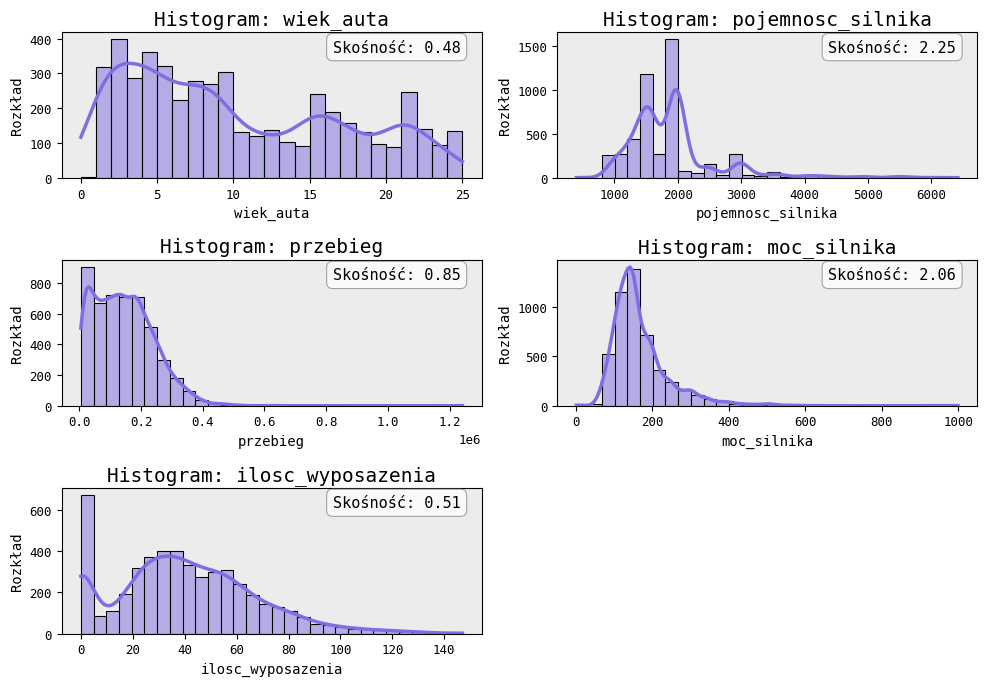

In [35]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(10, 7))
axes = axes.flatten()

for i, col in enumerate(kolumny_numeryczne):
    skośność = sp.stats.skew(df[col])

    if col == 'wiek_auta':
        min_val = df[col].min()
        max_val = df[col].max()
        bins = max_val - min_val
    else:
        bins = 30

    sns.histplot(data=df, x=col, bins=bins, kde=True, ax=axes[i])

    axes[i].text(
        0.95, 0.95, 
        f'Skośność: {skośność:.2f}',
        transform=axes[i].transAxes, 
        verticalalignment='top', 
        horizontalalignment='right',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.7, edgecolor='grey')
    )
    
    axes[i].set_title(f'Histogram: {col}')
    axes[i].set_ylabel('Rozkład')
    
fig.delaxes(axes[-1])

plt.tight_layout()

Rozkłady wszystkich zmiennych numerycznych charakteryzują się skośnością prawostronną. Oznacza to, że większa ilość obserwacji skupia się w dolnym zakresie wartości.

Dla zmiennej `ilosc_wyposazenia` oraz `wiek_auta` skośność jest umiarkowana, dla `przebieg` jest bardzo wyraźna, natomiast dla `moc_silnika` oraz `pojemnosc_silnika` skośność jest bardzo silna. 


### **Wykresy słupkowe dla podstawowych kolumn numerycznych**

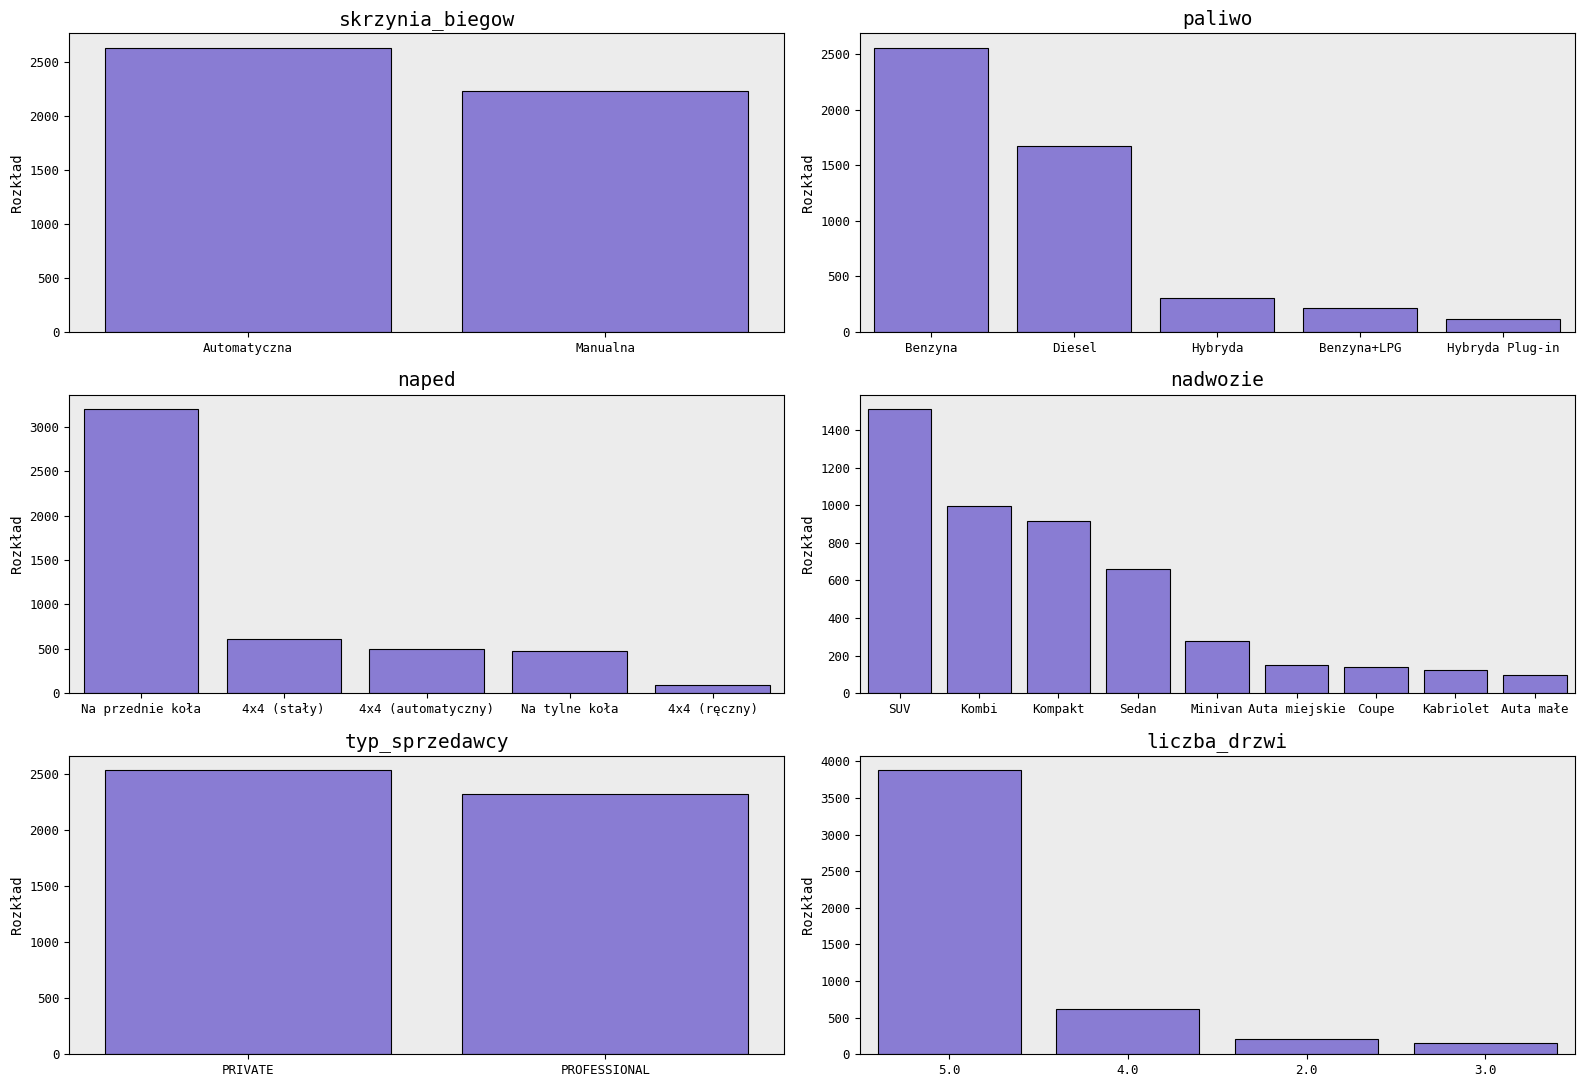

In [36]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(16, 11))
axes = axes.flatten()
kolumny = kolumny_kategoryczne_podstawowe.drop(['marka', 'wojewodztwo', 'kolor'])
for i, col in enumerate(kolumny):

    if col == 'wiek_auta':
        min_val = df[col].min()
        max_val = df[col].max()
        bins = max_val - min_val
    else:
        bins = 30 

    sns.countplot(data=df, x=col, ax=axes[i], order=df[col].value_counts().index)
    
    axes[i].set_title(f'{col}')
    axes[i].set_ylabel('Rozkład')
    axes[i].set_xlabel('')
    

plt.tight_layout()

Wykres słupkowy przedstawia liczebność (częstość) występowania poszczególnych rodzajów paliwa w analizowanym zbiorze danych.

Dla Zmiennej `paliwo` widzimy dominację ze strony tradycjnego napędu spalinowego. Pojazdy z systemem elektrycznym stanowią zdecydowaną mniejszość

Dla zmiennej `napęd` przeważa napęd na przednie koła, to najpopularniejsze rozwiązanie ze względu na prostotę i łatwość konserwacji konstrukcji.

Dla zmiennej `nadwozie` SUV-y zdominowały rynek samochodowy, tak też jest w tym zbiorze danych. 

Dla zmiennej `typ sprzedawcy` widzimy niewielką różnicę, z przewagą sprzedawców prywatnych.

Dla zmiennej `skrzynia biegow` kategoria skrzyń automatycznych jest wyraźnie bardziej liczna.

Dla zmiennej `liczba drzwi` wiekszość pojazdów ze zbioru danych jest klasycznie pięciodrzwiowa.

### **Wykresy słupkowe dla kategorycznych kolumn wyposażenia**

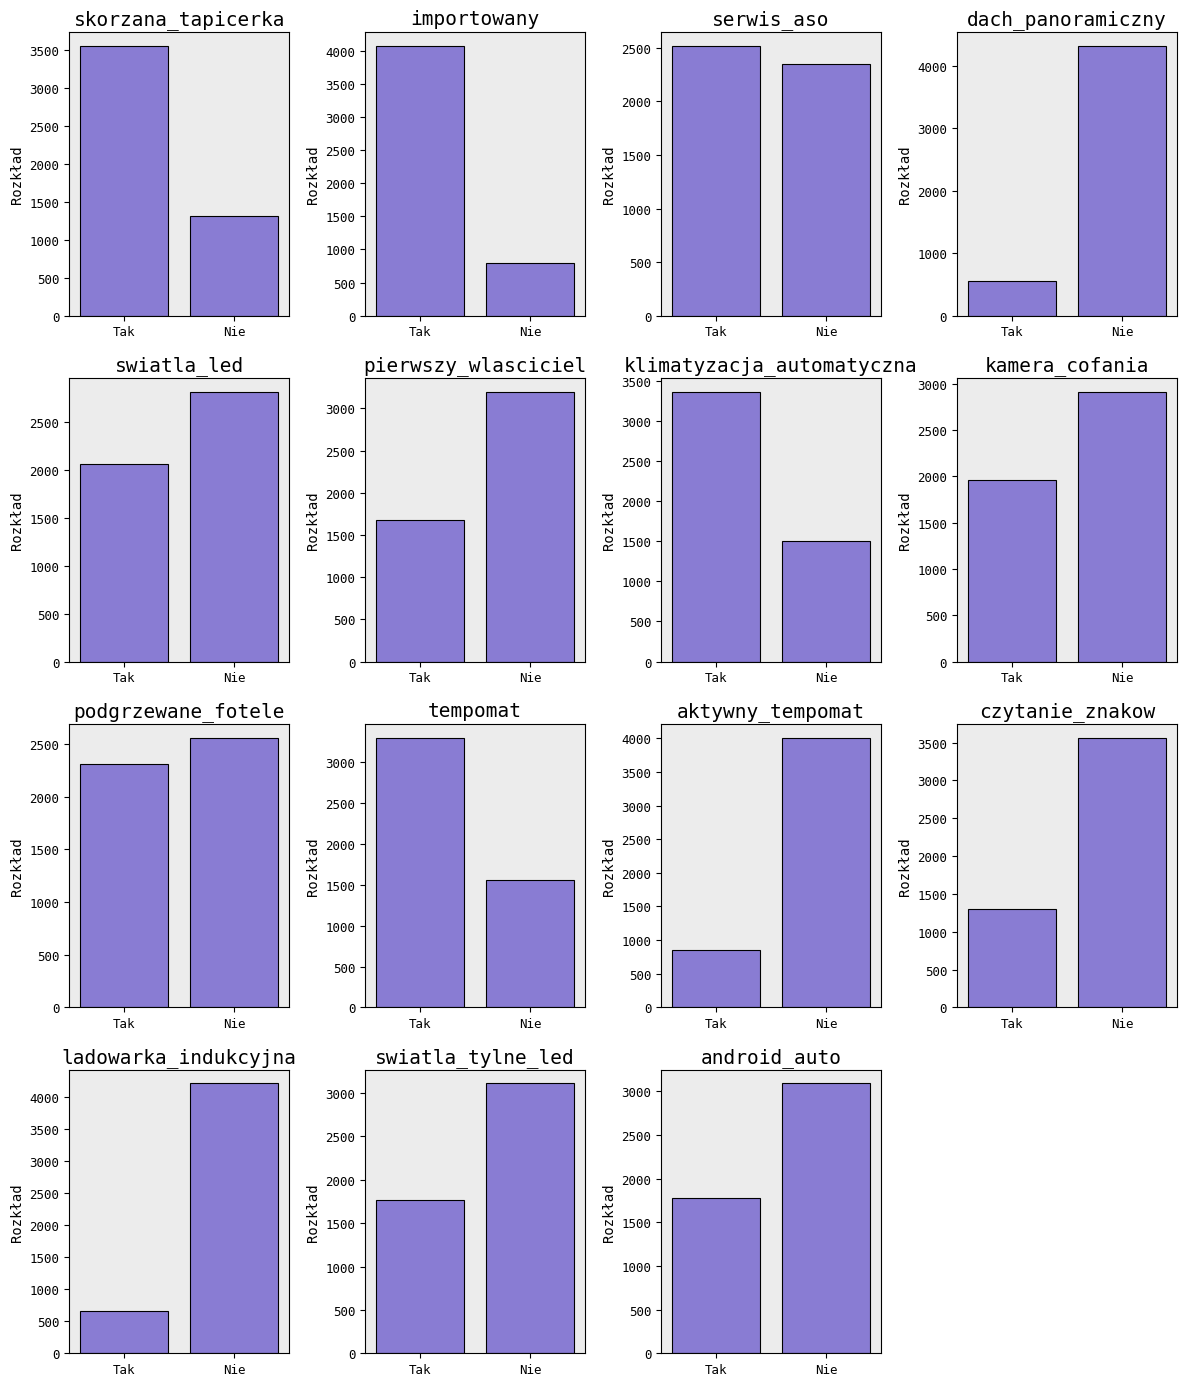

In [37]:
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(12, 14))
axes = axes.flatten()


for i, col in enumerate(kolumny_kategoryczne_wyposazenie):

    if col == 'wiek_auta':
        min_val = df[col].min()
        max_val = df[col].max()
        bins = max_val - min_val
    else:
        bins = 30 

    sns.countplot(data=df, x=col, ax=axes[i], order=["Tak", "Nie"])
    
    axes[i].set_title(f'{col}')
    axes[i].set_ylabel('Rozkład')
    axes[i].set_xlabel('')
    
fig.delaxes(axes[-1])
plt.tight_layout()

### **Wykres słupkowy dla zmiennej kolor**

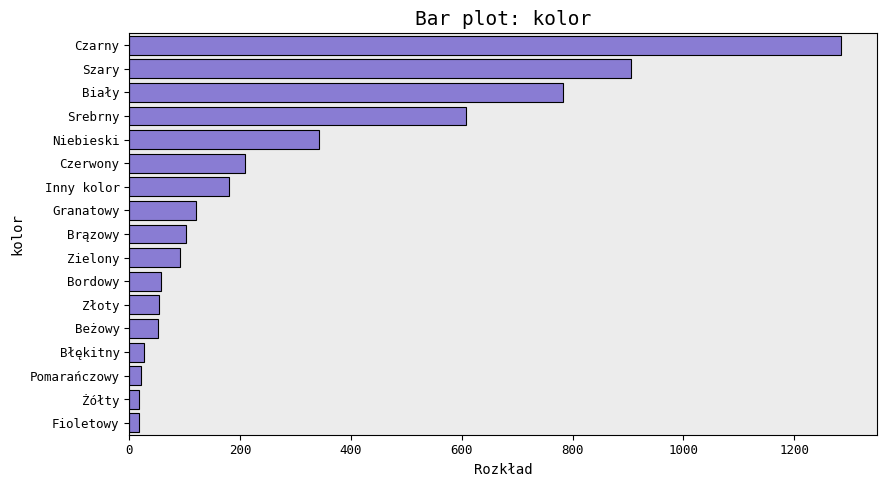

In [38]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(9,5))

for i, col in enumerate(['kolor']):
    sns.countplot(data=df, y=col, ax=axes, order=df[col].value_counts().index, )
    
    axes.set_title(f'Bar plot: {col}')
    axes.set_xlabel('Rozkład')

plt.tight_layout()

Zmienna `kolor` klasyczne i stonowane kolory są najpopularniejsze, jednakże kategoria `Inny kolor` reprezentuje sumę wystąpień nielicznych kolorów, jest ich około 120.

### **Wykres słupkowy dla kolumny województwo z porównaniem do liczebności ludności**

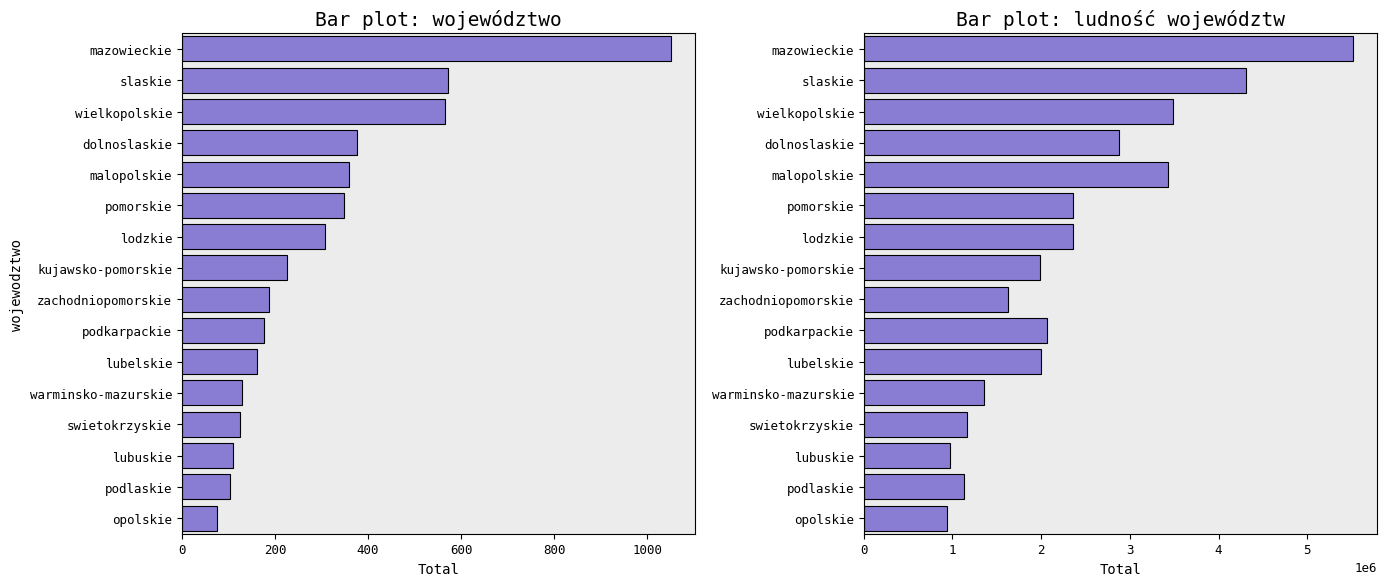

In [39]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14,6))
LUDNOSC_WOJEWODZTW = {
    "mazowieckie": 5510618,
    "slaskie": 4305126,
    "wielkopolskie": 3484177,
    "malopolskie": 3429685,
    "dolnoslaskie": 2874496,
    "pomorskie": 2359956,
    "lodzkie": 2354135,
    "podkarpackie": 2067139,
    "lubelskie": 2003475,
    "kujawsko-pomorskie": 1990323,
    "zachodniopomorskie": 1626876,
    "warminsko-mazurskie": 1353374,
    "swietokrzyskie": 1163001,
    "podlaskie": 1135201,
    "lubuskie": 972140,
    "opolskie": 933349
}

sns.countplot(data=df, y='wojewodztwo', ax=axes[0], order=df['wojewodztwo'].value_counts().index)   
axes[0].set_title(f'Bar plot: województwo')
axes[0].set_xlabel('Total')

sns.barplot(data=pd.Series(LUDNOSC_WOJEWODZTW), ax=axes[1], order=df['wojewodztwo'].value_counts().index, orient='h')
axes[1].set_title(f'Bar plot: ludność województw')
axes[1].set_xlabel('Total')


plt.tight_layout()

Liczność występowania ogłoszeń pojazdów w poszczególncyh wojewodztwach jest skorelowana z ilością ludności w poszczególnych województwach.

### **Wykres punktowy dla zmiennych numerycznych wraz z obliczoną korelacją**

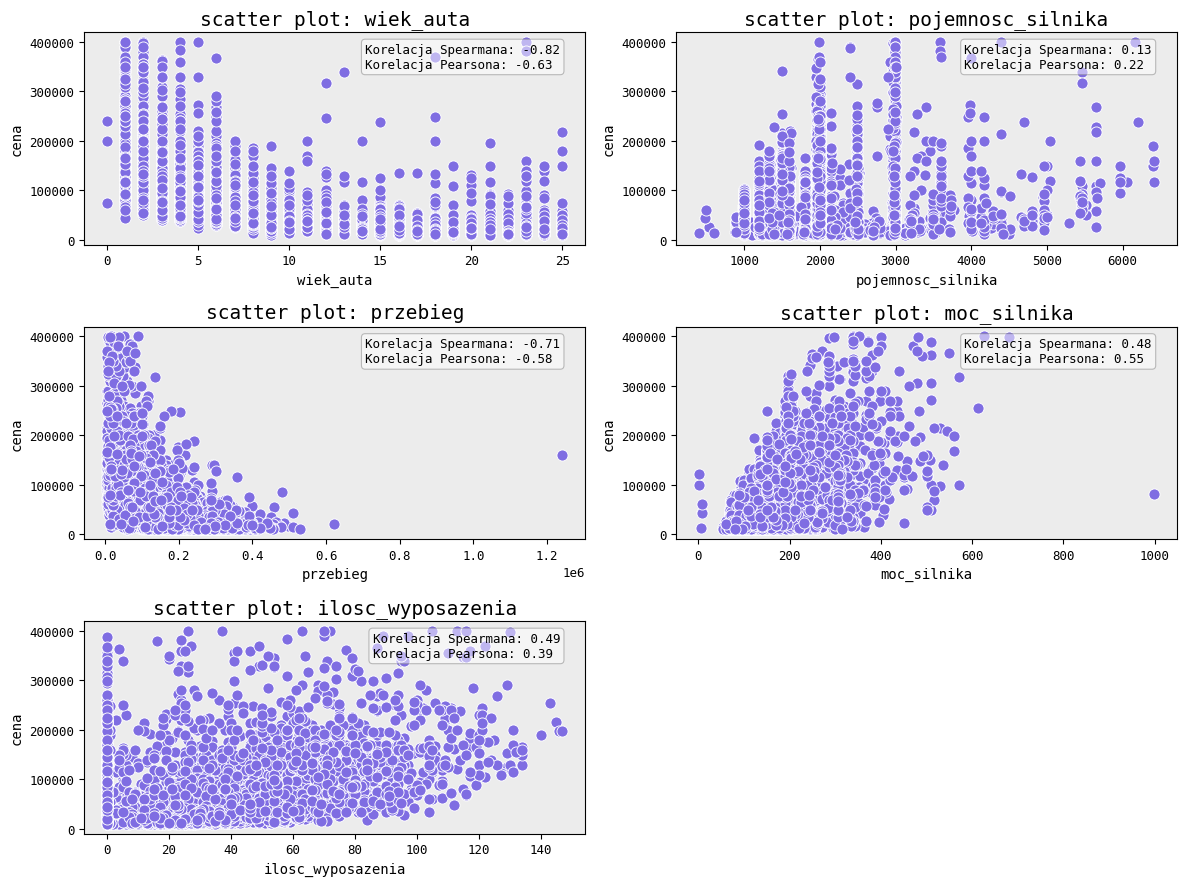

In [40]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12,9))
axes = axes.flatten()
for i, col in enumerate(kolumny_numeryczne):

    sns.scatterplot(data=df, y='cena', x=col, ax=axes[i])
    
    axes[i].text(
        0.95, 0.95, 
        f'Korelacja Spearmana: {df["cena"].corr(df[col], method="spearman"):.2f}\nKorelacja Pearsona: {df["cena"].corr(df[col], method="pearson"):.2f}',
        transform=axes[i].transAxes, 
        fontsize=9,
        verticalalignment='top', 
        multialignment='left',
        horizontalalignment='right',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.5, edgecolor='grey')
    )

    axes[i].set_title(f'scatter plot: {col}')
    
fig.delaxes(axes[-1])
plt.tight_layout()

Zmienna `wiek_auta` korelacja liniowa Pearsona jest umiarkowanie ujemna. Korelacja nieliniowa Spearmana, również ujemna, jest silna.

Zmienna `pojemnosc_silnika` widzimy, że obydwa współczynniki korelacji wykazują niski poziom, pojemność silnika może nie mieć znaczącego wpływu na cenę.

Zmienna `przebieg` korelacja Pearsona jak i Spearmana wskazują na umiarkownie ujemną zależność, widzimy jednak, że pojazdy z górnego zakresu ceny zdecydowanie częściej charakteryzują się niskim przebiegiem.

Zmienna `moc_silnika` najsilniej zależna liniowo zmienna od ceny. Zależność jest dodatnia, wraz ze wzrostem mocy silnika wzrasta jego cena.

### **Macierz korelacji (heat map) zmiennych numerycznych**

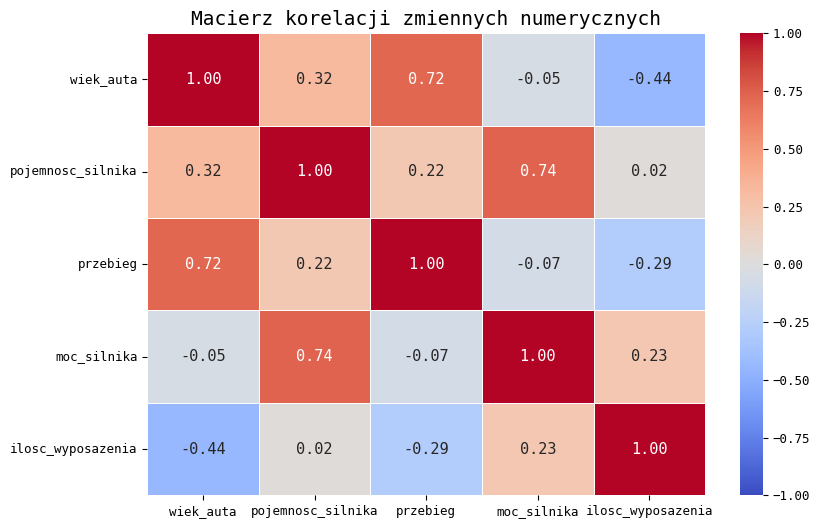

In [41]:
macierz_korelacji = df[kolumny_numeryczne].corr()
sns.heatmap(
    macierz_korelacji, 
    annot=True,       
    cmap='coolwarm',   
    fmt=".2f",        
    linewidths=0.7,   
    vmin=-1, vmax=1
)
plt.title('Macierz korelacji zmiennych numerycznych')
plt.show()

Na przedstawionym wykresie korelacji wyraźne są dwa związki między zmiennymi objaśniającymi:

`wiek_auta` - `przebieg`, współczynnik korelacji wynosi 0,72. 

`pojemnosc_silnika` - `moc_silnika`, współczynnik korelacji 0,74.

Z perspektywy biznesowej związki te są naturalne, pojazdy z upływem lat są dłużej eksploatowane co odzwierciedla ich przebieg. Patrząc na budowę i charakerystykę silników spalinowych wiemy, że pojemność skokowa pozwala na generowanie większej mocy.

Zjawisko to nazywamy współliniowością, potencjalnie niesie ona ze sobą negatywne skutki, widoczne w późniejszej fazie budowy modelu.

### **Wykres gęstości cen z podziałem na paliwa**

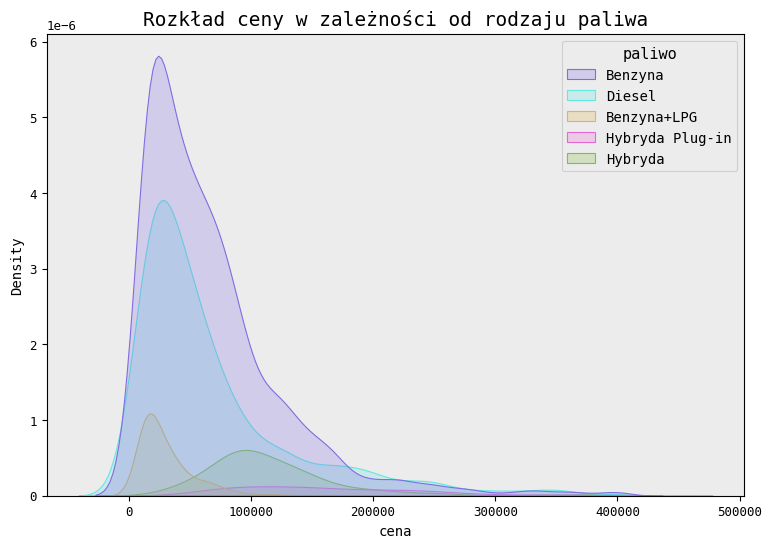

In [42]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(9,6))
sns.kdeplot(data=df, x='cena', hue='paliwo', fill=True, ax=axes)
plt.title('Rozkład ceny w zależności od rodzaju paliwa')
plt.show()

Wszystkie rozkłady charakteryzują się silną skośnością prawostronną. Oznacza to, że we wszystkich kategoriach zdecydowana większość samochodów koncentruje się w niższych przedziałach cenowych

`Benzyna` i `Diesel`, rozkład tych dwóch segmentów jest bardzo podobny pod względem kształtu jak i położenia.

`Hybryda`, wnioskując z rozkładu można stwierdzić, że ceny pojazdów z tym napędem są wyższe oraz bardziej zróżnicowane. Rozkład jest platokurtyczny. 

`Benzyna+LPG`, to najtańszy segment pojazdów, powyżej 100 000 zł samochody te występują bardzo rzadko.





### **Wykresy pudełkowe dla kolumn kategorycznych podstawowych**

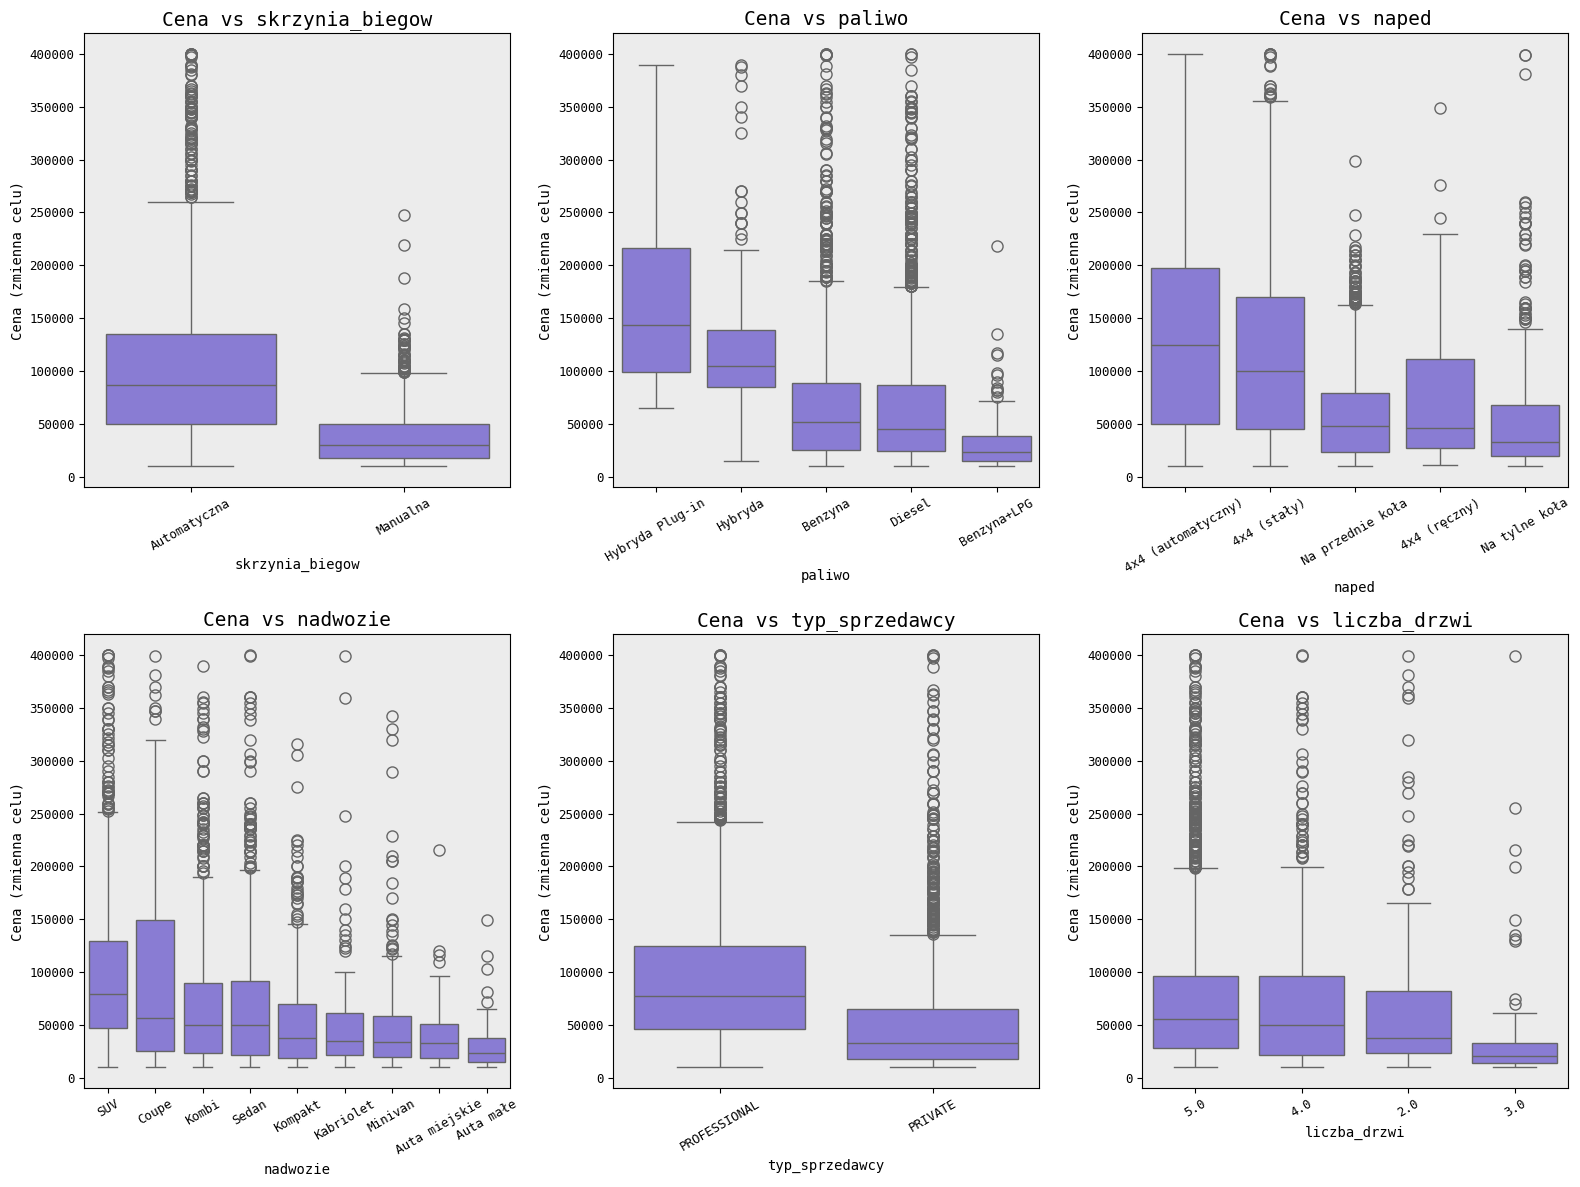

In [43]:
zmienna_celu = 'cena'
zmienne = ["skrzynia_biegow", "naped", "nadwozie", "paliwo", "typ_sprzedawcy"]

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(kolumny_kategoryczne_podstawowe.drop(['marka', 'wojewodztwo', 'kolor'])):
    order = df.groupby(col)[zmienna_celu].median().sort_values(ascending=False).index

    sns.boxplot(data=df, x=col, y=zmienna_celu, ax=axes[i], order=order)
    
    axes[i].set_title(f'Cena vs {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Cena (zmienna celu)')
    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()



Wykresy pudełkowe cen z rozróżniem na poszczególne kategorie zmiennych jakościowych, dzięki nim jesteśmy w stanie ocenić jak rozkłada się cena dla poszczególnych wartości.

`skrzynia_biegow`, przeciętny pojazd ze skrzynią automatyczna jest znacznie droższy od przeciętnego pojazdu ze skrzynią manualną. Ceny pojazdów ze automatem są bardziej zróżnicowane.

`paliwo`, pojazdy elektryczne mają największą wartość środkową, są również znacząco zróżnicowane. Pojazdy z napędem benzynowym mają nieznacznie większą medianę od pojazdów z silnikiem Diesla. Najtańsze są samochody z Benzyna+LPG.

`napęd`, pojazdy z napędem 4x4, niezależnie od charakterystyki działania mają najwyższą medianę, natomiast pojazdy z napędem na przód są uogólniając najtańsze oraz słabo zróżnicowane.

`nadwozie`, pojazdy coupe są najdroższe, może to wynikać z faktu, że w takim nadwoziu występują pojazdy sportowe marek premium, poza tym można stwierdzić, że wraz z malejącym rozmiarem pojazdu spada również cena.

`czy_uszkodzony`, zgodnie z intuicją biznesową, pojazdy uszkodzone charakteryzują się znacznie niższą wartością.

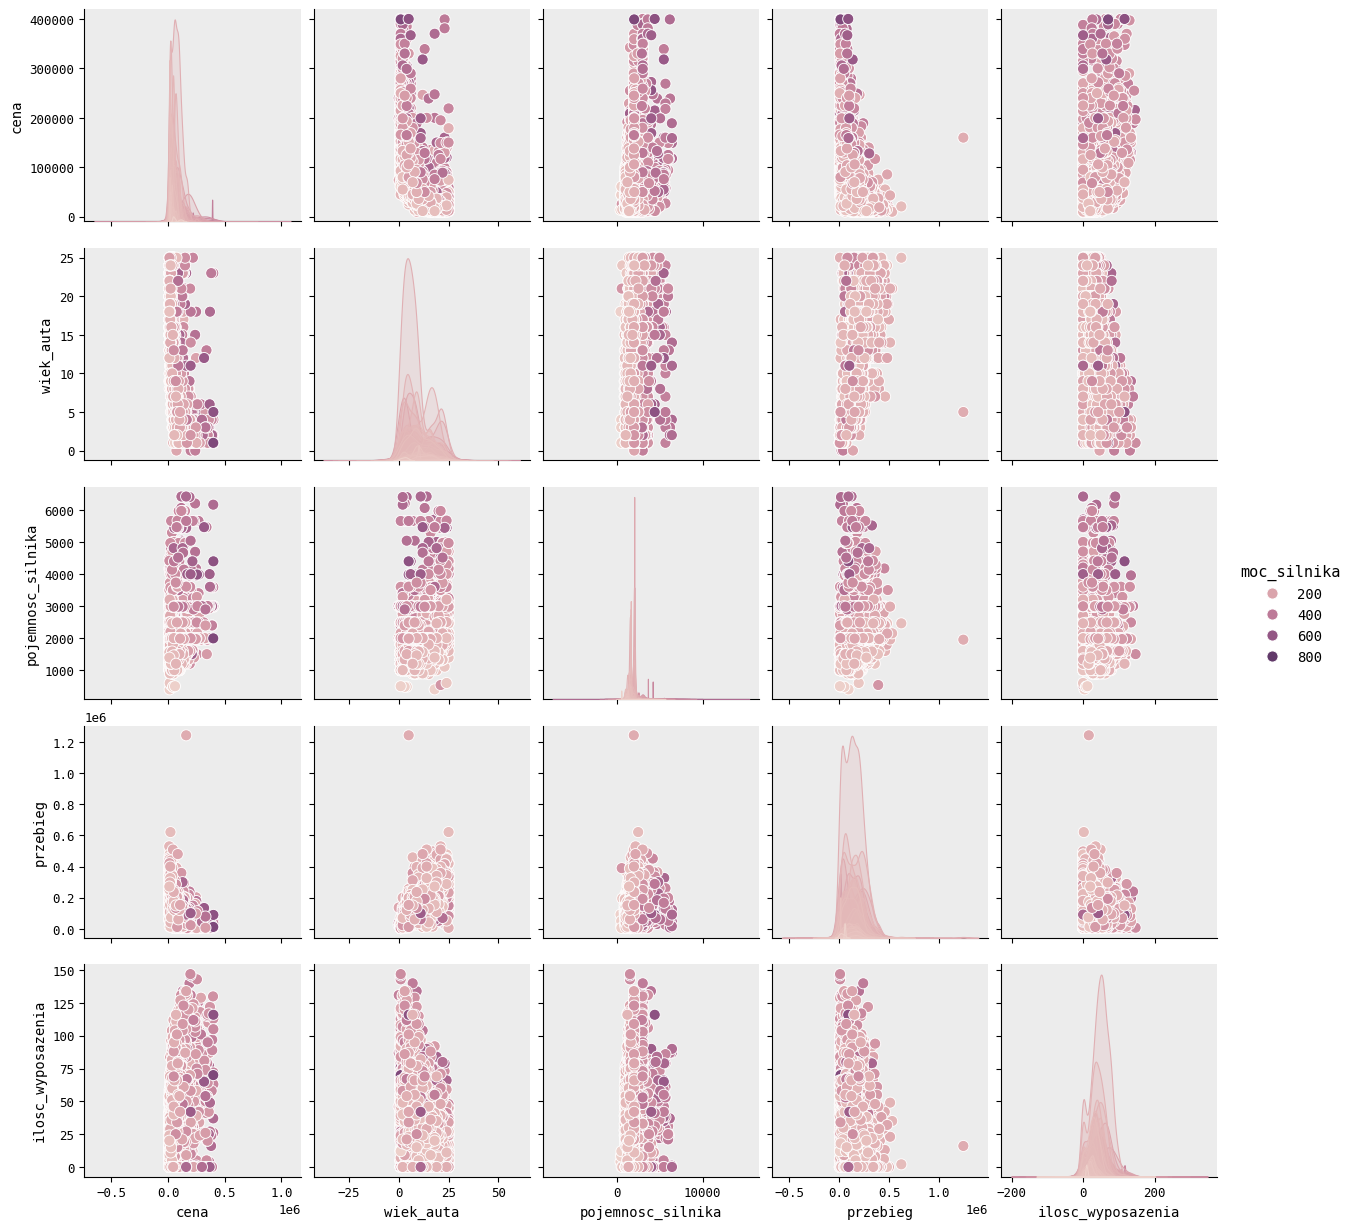

In [44]:
sns.pairplot(df, hue='moc_silnika')
plt.show()

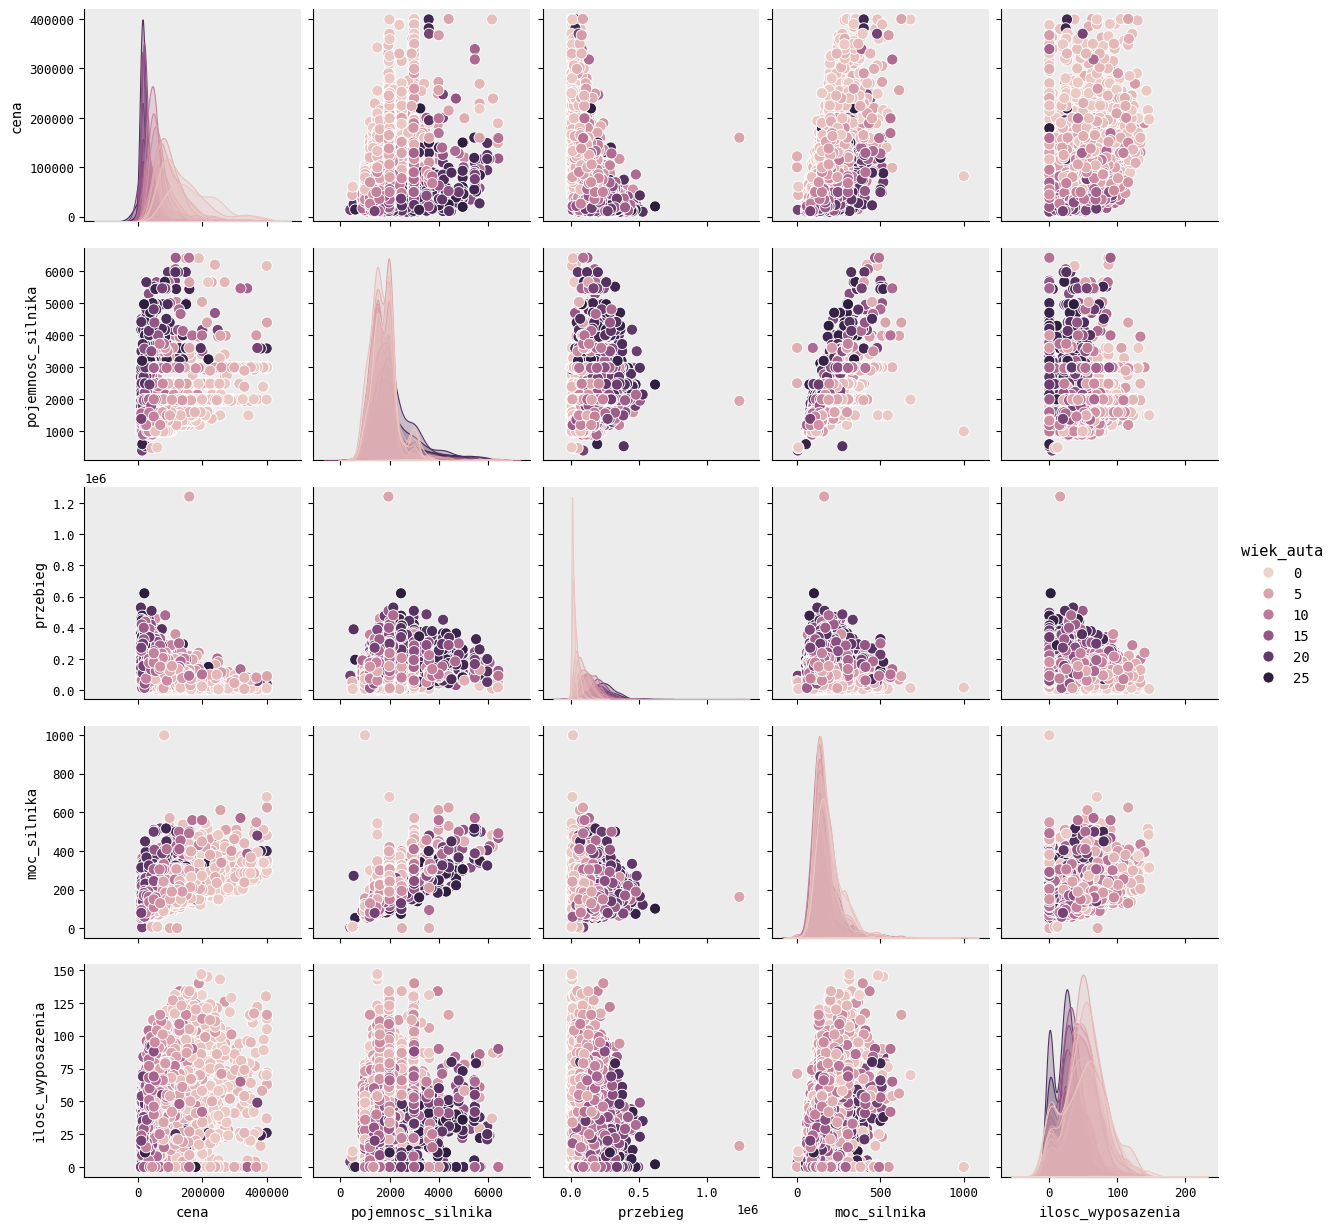

In [45]:
sns.pairplot(df, hue='wiek_auta')
plt.show()